# 02 — Exploratory Data Analysis & Business KPIs

**Input:** `data/clean.parquet` (produced by notebook 01)

In [1]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
from warnings import filterwarnings

filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color   = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color    = viridis_colors[2]
danger_color    = '#800000'
neutral_color   = viridis_colors[4]

In [3]:
df = pd.read_parquet('data/clean.parquet')
print('Shape:', df.shape)
df.head(3)

Shape: (172765, 21)


,type,days_shipping_real,days_shipment_scheduled,sales_per_customer,delivery_status,late_delivery_risk,category_name,customer_country,customer_segment,department_name,...,order_item_profit_ratio,sales,order_item_total,order_profit,order_region,order_status,product_name,product_price,shipping_date,shipping_mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,...,0.29,327.75,314.640015,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,...,-0.80,327.75,311.359985,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,...,-0.80,327.75,309.720001,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class


## 1. Feature Engineering

| Feature | Description |
|---|---|
| `order_processing_time` | Calendar days from order to shipment |
| `delay` | Processing time minus scheduled shipment days |
| `is_delayed` | Boolean — order shipped after scheduled date |
| `order_month` / `order_day` / `order_hour` | Temporal breakdowns |
| `profitability_category` | Profit / Loss / Breakeven label |

In [4]:
df['order_processing_time'] = (df['shipping_date'] - df['order_date']).dt.days
df['delay']     = df['order_processing_time'] - df['days_shipment_scheduled']
df['is_delayed'] = df['delay'] > 0

df['order_month'] = df['order_date'].dt.month
df['order_day']   = df['order_date'].dt.day_name()
df['order_hour']  = df['order_date'].dt.hour

df['profitability_category'] = np.where(
    df['order_profit'] > 0, 'Profit',
    np.where(df['order_profit'] < 0, 'Loss', 'Breakeven')
)

print('is_delayed distribution:')
print(df['is_delayed'].value_counts())

df.describe()

is_delayed distribution:
is_delayed
True     94523
False    78242
Name: count, dtype: int64


,days_shipping_real,days_shipment_scheduled,sales_per_customer,late_delivery_risk,order_date,order_item_profit_ratio,sales,order_item_total,order_profit,product_price,shipping_date,order_processing_time,delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991,0.120801,203.828493,183.165948,22.032360,141.278595,2016-06-16 03:25:14.452927,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,7.490000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,104.379997,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,163.990005,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,247.399994,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,1939.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,120.141871,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


## 2. Business KPIs

In [5]:
def format_kpi(value):
    if value >= 1e6:
        return f'{value / 1e6:.1f}M $'
    if value >= 1e3:
        return f'{value / 1e3:.1f}K $'
    return f'{value:.0f} $'


delayed_df = df[df['delay'] > 0]

metrics = {
    'Total Orders':                   len(df),
    'Late Deliveries':                len(delayed_df),
    '90th Percentile Delay (days)':   delayed_df['delay'].quantile(0.90),
    'On-Time Delivery %':             (1 - len(delayed_df) / len(df)) * 100,
    'Total Profit (Positive Orders)': format_kpi(
        df.loc[df['order_profit'] > 0, 'order_profit'].sum()
    ),
    'Total Loss (Delayed Orders)':    format_kpi(
        df.loc[(df['delay'] > 0) & (df['order_profit'] < 0), 'order_profit'].sum()
    ),
}

print('\n--- BUSINESS KPIs ---\n')
for k, v in metrics.items():
    print(f'  {k}: {v:.2f}' if isinstance(v, float) else f'  {k}: {v}')


--- BUSINESS KPIs ---

  Total Orders: 172765
  Late Deliveries: 94523
  90th Percentile Delay (days): 3.00
  On-Time Delivery %: 45.29
  Total Profit (Positive Orders): 7.5M $
  Total Loss (Delayed Orders): -2055610 $


## 3. Profitability Distribution

profitability_category
Profit       80.66
Loss         18.69
Breakeven     0.65
Name: proportion, dtype: float64


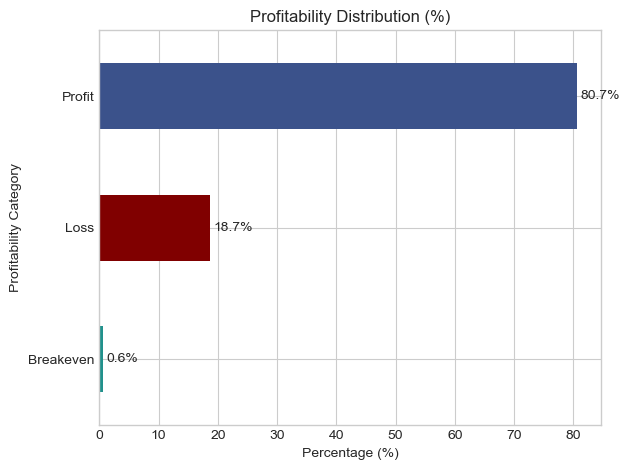

In [6]:
profit_counts = df['profitability_category'].value_counts(normalize=True) * 100
print(profit_counts.round(2))

profit_counts.sort_values().plot(
    kind='barh',
    color=[accent_color, danger_color, secondary_color]
)

plt.xlabel('Percentage (%)')
plt.ylabel('Profitability Category')
plt.title('Profitability Distribution (%)')

# Add labels
for i, v in enumerate(profit_counts.sort_values()):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

## 4. Delay Distribution & Profit Analytics

In [7]:
profit_metrics = (
    df.groupby('delay')['order_profit']
    .agg(mean_profit='mean', total_profit='sum', order_count='count')
    .reset_index()
)

delay_distribution = (
    df['delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()
delay_distribution.columns = ['delay_days', 'percentage']

print('Profit Metrics by Delay Day:')
display(profit_metrics.round(1))

print('\nDelay Distribution (%):')
display(delay_distribution)

Profit Metrics by Delay Day:


,delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,delay_days,percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


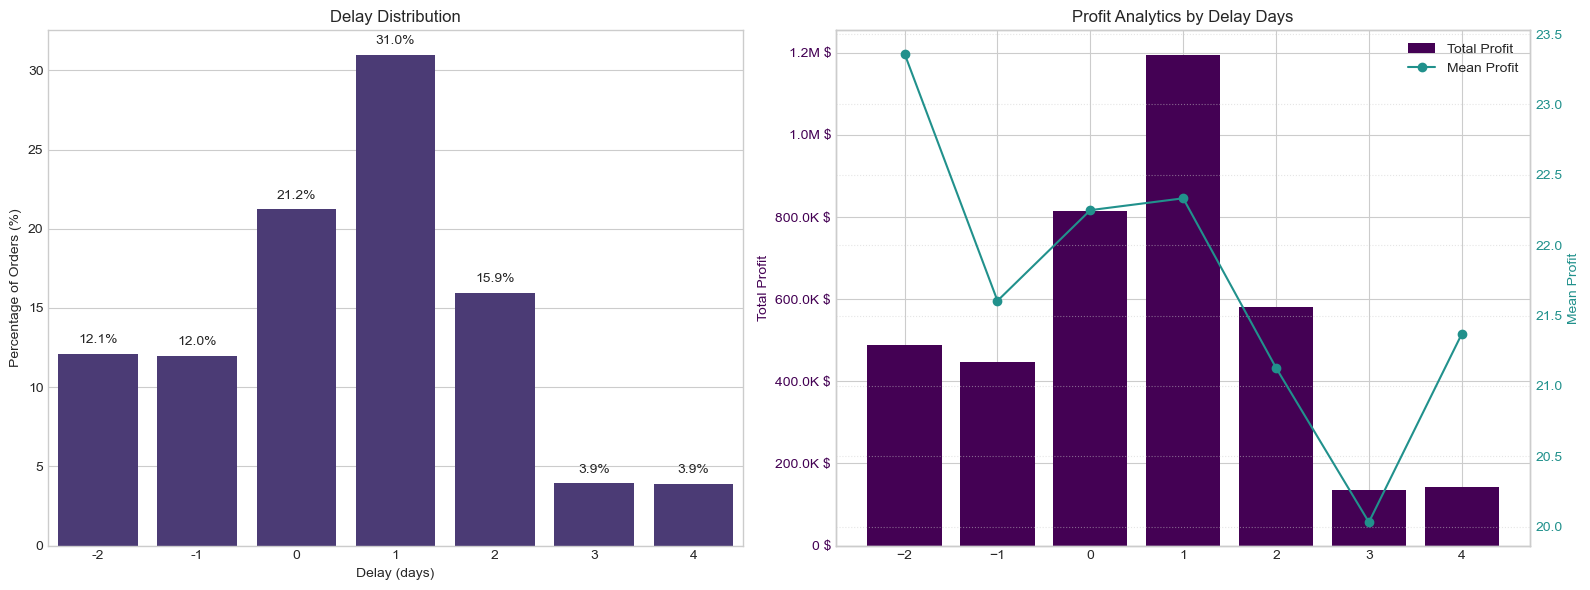

In [8]:
def format_axis(value, _):
    if value >= 1e6:
        return f'{value / 1e6:.1f}M $'
    if value >= 1e3:
        return f'{value / 1e3:.1f}K $'
    return f'{value:.0f} $'


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='delay_days', y='percentage', data=delay_distribution, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('Percentage of Orders (%)')
for bar in ax1.patches:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2, h + 0.5,
        f'{h:.1f}%', ha='center', va='bottom'
    )

ax2.bar(
    profit_metrics['delay'], profit_metrics['total_profit'],
    color=primary_color, label='Total Profit'
)
ax2.set_ylabel('Total Profit', color=primary_color)
ax2.tick_params(axis='y', labelcolor=primary_color)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_axis))

ax3 = ax2.twinx()
ax3.plot(
    profit_metrics['delay'], profit_metrics['mean_profit'],
    marker='o', color=accent_color, label='Mean Profit'
)
ax3.set_ylabel('Mean Profit', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)
ax3.set_title('Profit Analytics by Delay Days')
ax3.set_xlabel('Delay Days')
ax3.grid(True, linestyle=':', alpha=0.5)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

## 5. Business Recommendations

Based on the KPI and profitability analysis:

| Finding | Recommendation |
|---------|---------------|
| **54.7 % delay rate** — more than half of all orders arrive late | Set an internal target of ≤ 25 % and treat this as a top-tier operational KPI |
| **Delayed orders drove ~$2 M in losses** against $7.5 M in positive-profit orders | Every percentage-point improvement in on-time delivery is worth roughly $73 K in recovered margin |
| **31 % of orders are 1 day late** (the largest single delay bucket) | A 1-day buffer added to Standard Class SLAs would reclassify the majority of "late" orders as on-time at low cost |
| **Breakeven orders are minimal** | Pricing and discount policy is reasonably clean; focus effort on operations, not repricing |